# Client-Driven Classification Analysis

## Project Overview

This project develops and evaluates machine-learning classification models under clearly defined client performance requirements.

The workflow includes data-quality validation, exploratory analysis, preprocessing, baseline modelling, hyperparameter optimisation, model comparison and final evaluation on an independent test set.

## Overview


The main aims of this project are:

- to use the best practice machine learning workflow for producing a solution to a client's problem;
- to visualise and clean data;
- to train and optimise a selection of models, then choose the best;
- to obtain an unbiased measurement of the final model's performance;
- to interpret results clearly and concisely.

This relates to the following ACS CBOK areas: abstraction, design, hardware and software, data and information, HCI and programming.


# Scenario

A client approaches you to solve a machine learning problem for them.  They run a pathology lab that processes histological images for healthcare providers and they have created a product that measures most of the same features as in the *Wisconsin breast cancer data set* though using different acquisitions and processing methods. Their method employs efficient stochastic sampling, making it much faster than existing methods, although slightly noisier. This method does not measure any of the 'worst' features that appear in the *Wisconsin Breast Cancer Data Set*. They want to be able to diagnose *malignant* cancer (and distinguish them from *benign* growths) by employing machine learning techniques, and they have asked you to implement this for them.

Their requirements are:
 - 1) Have at least a 90% probability of detecting malignant cancer when it is present;
 - 2) Ensure that no more than 1 in 5 healthy cases (those with benign growths) result in a false positive (labeled as malignant).



## 1. Load data, visualise it and identify erroneous values
 - Load the data.
 - Extract the feature names and label names for use later on.
 - Provide at least one text summary of the dataset. This should include key information and characteristics of the data.
 - Create one graphical plot per feature. Each plot must display the feature values for the two classes (malignant and benign) separately on a single axis/panel.
 - Clearly label the graphical plots with respect to feature names, axes, classes, etc.
 - Identify any erroneous values in the dataset during the data visualisation or summary steps. Determine and implement, here or later, the appropriate action to handle these values (e.g., removal, correction, or none).

In [ ]:

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Common imports
import numpy as np
import time

# Pandas for overview
import pandas as pd

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"
from sklearn import tree
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

# Plot setup
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
mpl.rc('figure', dpi=80)
plt.close('all')

import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

### 1.1 Data Summary and Erroneous Value Processing

In [2]:
# Your code here
df = pd.read_csv('assignment2_data_2024.csv')
data = df.copy()

In [3]:
data.head()

,label,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error
0,malignant,15.494653829645529,15.902542,103.008265,776.437239,0.104239,0.168660,0.170572,0.085668,0.205053,...,0.653654,1.096678,4.962255,80.619370,0.006669,0.034950,0.043568,0.013765,0.024093,0.004928
1,malignant,16.229870799611437,18.785613,105.176755,874.712003,0.091843,0.092548,0.081681,0.053670,0.180435,...,0.445451,1.043931,3.005373,50.407958,0.006352,0.019998,0.025324,0.012172,0.018084,0.003582
2,malignant,16.34567074196476,20.114076,107.083804,872.563251,0.099924,0.123799,0.128788,0.078310,0.189756,...,0.549625,1.057447,3.643671,62.732851,0.006757,0.031325,0.034350,0.015150,0.021459,0.004066
3,maligant,13.001009157806651,19.876997,85.889775,541.281012,0.113423,0.173069,0.146214,0.069574,0.212078,...,0.430693,1.202955,3.051434,33.614356,0.007930,0.044881,0.042972,0.014556,0.035670,0.005981
4,malignant,16.416060073302194,17.397533,107.857386,891.516818,0.097321,0.111530,0.125971,0.068575,0.179562,...,0.525532,1.045900,3.747194,59.164555,0.008718,0.024231,0.039763,0.014202,0.019236,0.004115


After browsing the dataset generally, it is obvious that there is a typo of 'maligant', which might influence the distribution of each features. To display a better graphical plot per feature, this erroneous will be dealt firstly.

In [4]:
data['label'] = data['label'].replace('maligant', 'malignant')

In [5]:
# Extract the feature names and label names
features = data.columns[1:] 
labels  = data.columns[0]

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    220 non-null    object 
 1   mean radius              220 non-null    object 
 2   mean texture             220 non-null    float64
 3   mean perimeter           220 non-null    float64
 4   mean area                220 non-null    float64
 5   mean smoothness          220 non-null    float64
 6   mean compactness         220 non-null    float64
 7   mean concavity           220 non-null    float64
 8   mean concave points      220 non-null    float64
 9   mean symmetry            220 non-null    float64
 10  mean fractal dimension   220 non-null    float64
 11  radius error             220 non-null    float64
 12  texture error            220 non-null    float64
 13  perimeter error          220 non-null    float64
 14  area error               2

All the features in the dataset should be numeric, but 'mean radius' is an object according to the `data.info()` summary of the dataset. To display the details of all features, convert the the type of 'mean radius' to float number.

In [7]:
data['mean radius'] = data['mean radius'].apply(pd.to_numeric, errors='coerce')

In [8]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,219.0,13.693313,2.176062,-14.292182,13.092060,13.647143,14.272883,18.200299
mean texture,220.0,18.991963,1.427635,15.349270,17.914319,18.928256,19.995859,24.430831
mean perimeter,220.0,89.866240,7.366180,74.690886,84.911981,88.587737,93.066393,121.247839
mean area,220.0,620.956227,106.419871,-2.645499,558.731832,603.806128,655.690435,1103.740620
mean smoothness,220.0,0.096480,0.004961,0.084651,0.092797,0.096457,0.099817,0.113423
mean compactness,220.0,0.102879,0.019819,0.075184,0.089531,0.098517,0.113276,0.192880
mean concavity,220.0,0.085281,0.026911,0.050771,0.066525,0.075748,0.098826,0.201971
mean concave points,220.0,0.046867,0.012548,0.028701,0.038106,0.042761,0.055337,0.100467
mean symmetry,220.0,0.181850,0.010816,0.157059,0.174944,0.180953,0.186354,0.226448
mean fractal dimension,220.0,0.103957,0.606979,0.058922,0.061139,0.062557,0.064184,9.065897


There exists negative values in 'mean radius' and 'mean area', which are impossible and need to be converted to `np.nan` value. 

In [9]:
data['mean radius'] = data['mean radius'].apply(lambda x: np.nan if x < 0 else x)
data['mean area'] = data['mean area'].apply(lambda x: np.nan if x < 0 else x)

Comparing mean, mininum and maximum value of each feature, the maximum value of 'mean fractal dimension' is far bigger than its mean value. Plot the scatter plot of 'mean fractal dimension' to find out the threhold of erroneous.

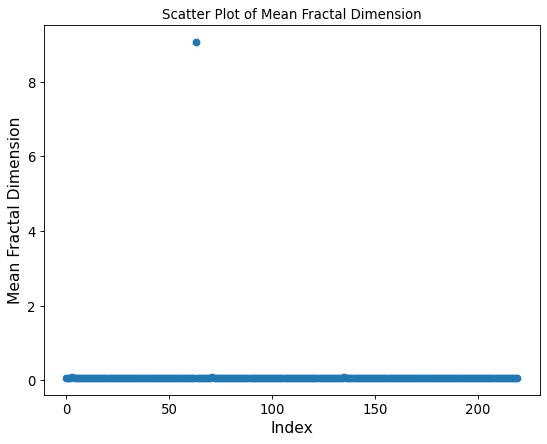

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(data.index, data['mean fractal dimension'])
plt.title('Scatter Plot of Mean Fractal Dimension')
plt.xlabel('Index')
plt.ylabel('Mean Fractal Dimension')
plt.show()

It is obvious that most mean fractal dimension are just bigger that 0. Set a boundary of 2 in this case to filter out abnomal data is resonable.

In [11]:
data['mean fractal dimension'] = data['mean fractal dimension'].apply(lambda x: np.nan if x > 2 else x)

In [12]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,218.0,13.821687,1.063649,11.560025,13.105327,13.654830,14.277530,18.200299
mean texture,220.0,18.991963,1.427635,15.349270,17.914319,18.928256,19.995859,24.430831
mean perimeter,220.0,89.866240,7.366180,74.690886,84.911981,88.587737,93.066393,121.247839
mean area,219.0,623.803723,97.903752,477.371592,559.838030,604.596268,655.885812,1103.740620
mean smoothness,220.0,0.096480,0.004961,0.084651,0.092797,0.096457,0.099817,0.113423
mean compactness,220.0,0.102879,0.019819,0.075184,0.089531,0.098517,0.113276,0.192880
mean concavity,220.0,0.085281,0.026911,0.050771,0.066525,0.075748,0.098826,0.201971
mean concave points,220.0,0.046867,0.012548,0.028701,0.038106,0.042761,0.055337,0.100467
mean symmetry,220.0,0.181850,0.010816,0.157059,0.174944,0.180953,0.186354,0.226448
mean fractal dimension,219.0,0.063035,0.002761,0.058922,0.061133,0.062525,0.064110,0.076091


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    220 non-null    object 
 1   mean radius              218 non-null    float64
 2   mean texture             220 non-null    float64
 3   mean perimeter           220 non-null    float64
 4   mean area                219 non-null    float64
 5   mean smoothness          220 non-null    float64
 6   mean compactness         220 non-null    float64
 7   mean concavity           220 non-null    float64
 8   mean concave points      220 non-null    float64
 9   mean symmetry            220 non-null    float64
 10  mean fractal dimension   219 non-null    float64
 11  radius error             220 non-null    float64
 12  texture error            220 non-null    float64
 13  perimeter error          220 non-null    float64
 14  area error               2

There are still some `np.nan` values due to missing data or identified erroneous values. These values will be imputed after the data is split to prevent data leakage.

### 1.2 Visualisation of features

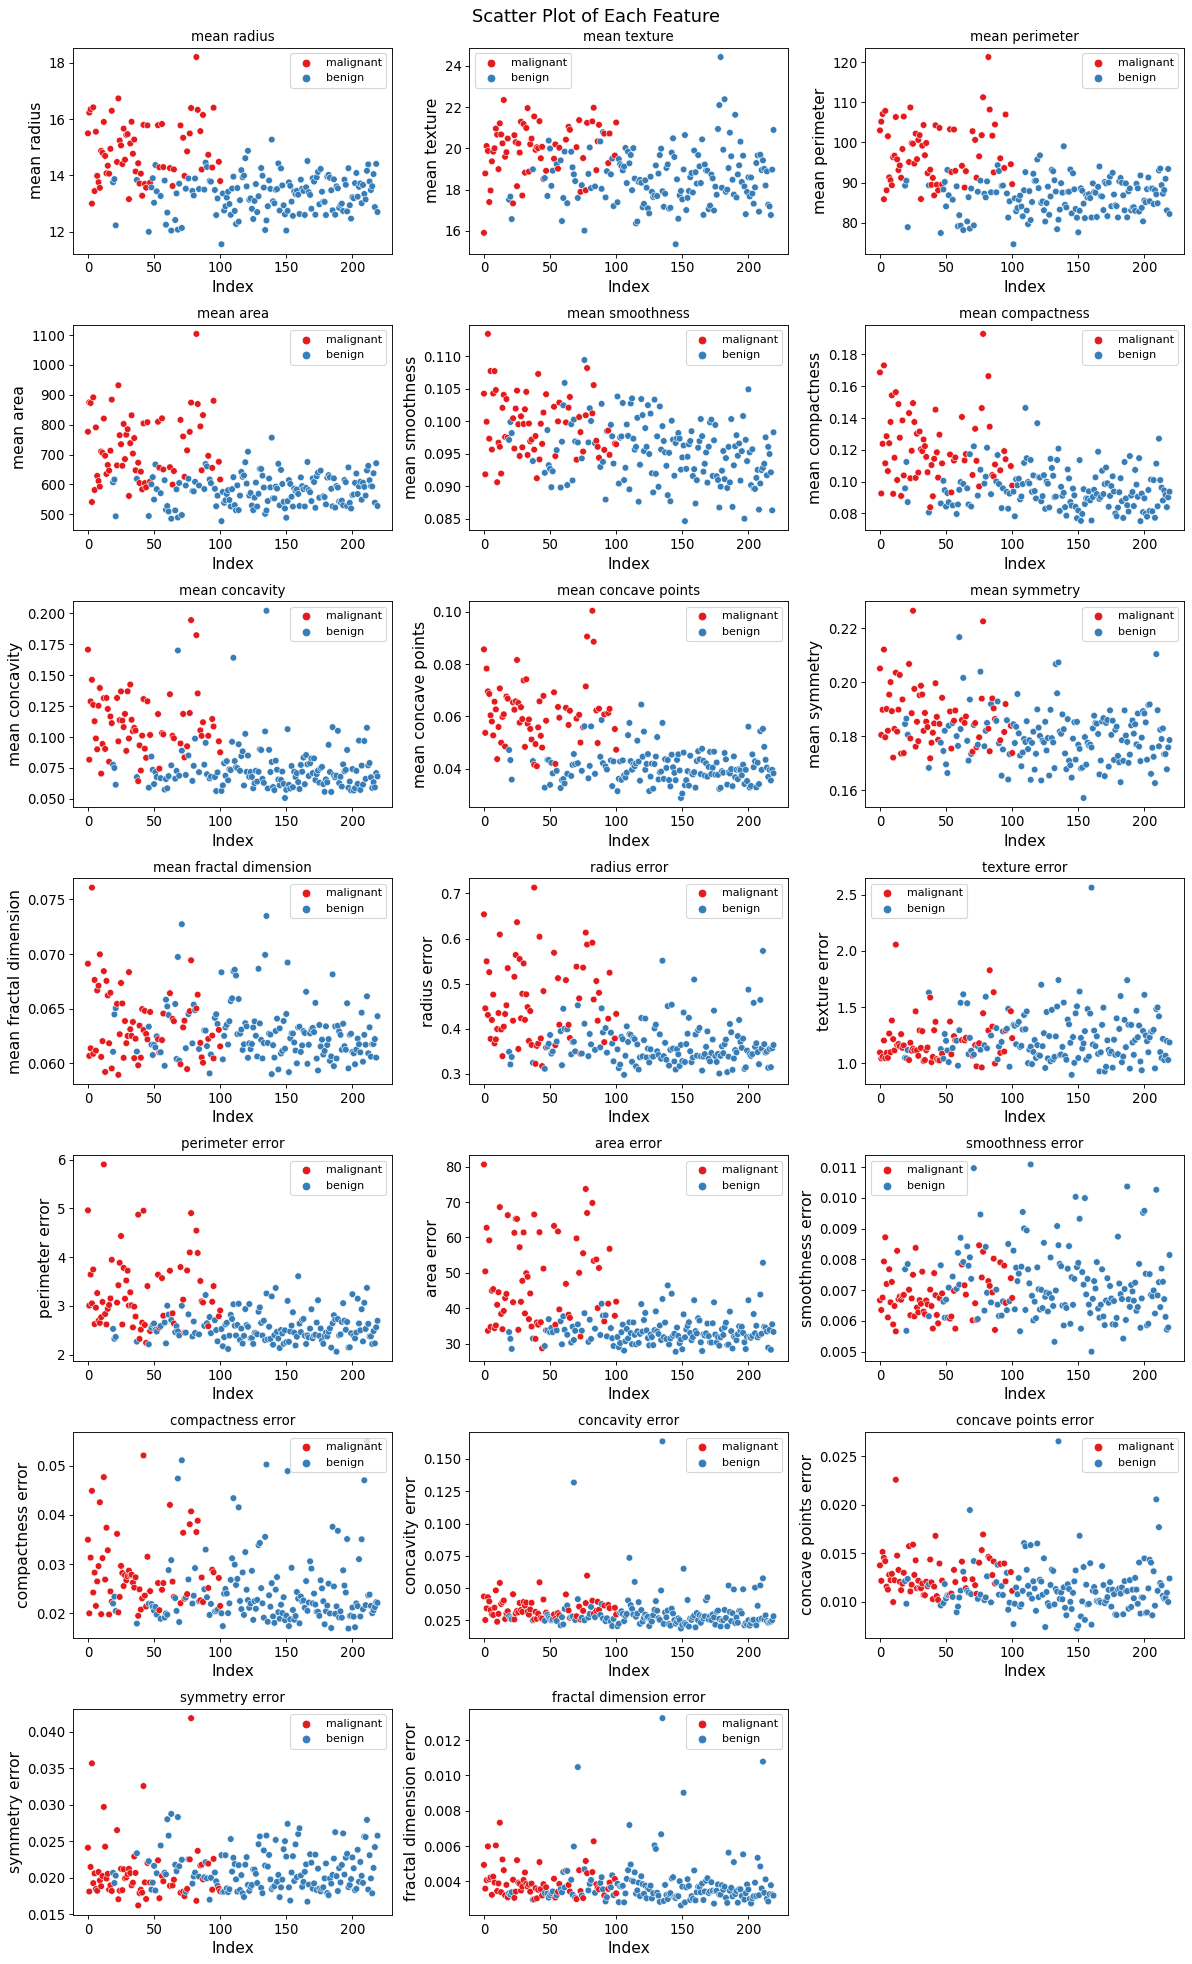

In [14]:
fig, axes = plt.subplots(7, 3, figsize=(15, 25))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(x=data.index, y=feature, hue='label', palette='Set1', data=data, ax=axes[i])
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('Index')
    axes[i].set_ylabel(feature)
    axes[i].legend()

fig.delaxes(axes[20])
    
fig.suptitle('Scatter Plot of Each Feature', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

## 2. Prepare data and models, and make baseline measurements [20%]
 - Split data into appropriate sets using the `stratify` option to obtain consistent proportions of classes in each set.
 - Decide on appropriate pre-processing steps for the data.
 - Implement a _very_ simple baseline model that makes purely random predictions of the class.
 - Measure the baseline performance with the following metrics:
   - accuracy
   - balanced accuracy: accounts for imblanaced datasets, defined as _(sensitivity + specificity)/2_
   - recall
   - precision
   - auc
   - f1score
   - fbeta_scores with beta=0.1
   - fbeta_score with beta=10
 - Also display a confusion matrix for the baseline predictions.
 - As a second baseline, implement an SGD classifier and fit it once (without hyper-parameter optimisation) and then display the same performance metrics and a confusion matrix for its results.

In [ ]:

from sklearn.metrics import fbeta_score, make_scorer

f10_scorer = make_scorer(fbeta_score, beta=10)
f01_scorer = make_scorer(fbeta_score, beta=0.1)

def f10_score(yt,yp):
    return fbeta_score(yt, yp, beta=10)

def f01_score(yt,yp):
    return fbeta_score(yt, yp, beta=0.1)

### 2.1 Data split and pre-processing

Create a new variable to represent the numeric value of 'malignant' as 1 and 'benign' as 0.  
Split the whole dataset into train - validation - test using `stratify` option.

In [16]:
data['new_label'] = data['label'].apply(lambda x: 1 if x == 'malignant' else 0)

In [17]:
bigtrain_set, test_set= train_test_split(data, test_size=0.15, random_state=42, stratify=data[labels])
train_set, val_set= train_test_split(bigtrain_set, test_size=0.1765, random_state=42, stratify=bigtrain_set[labels])

X_bigtrain = bigtrain_set[features] 
y_bigtrain = bigtrain_set['new_label']

X_train = train_set[features]
y_train = train_set['new_label']
X_test = test_set[features]
y_test = test_set['new_label']
X_val = val_set[features]
y_val = val_set['new_label']
print(f'Shapes are {[X_train.shape,y_train.shape,X_test.shape,y_test.shape,X_val.shape,y_val.shape]}')

Shapes are [(153, 20), (153,), (33, 20), (33,), (34, 20), (34,)]


### 2.2 Baseline - Random predictions

In [18]:
# Define a function that display the metrics 
def output_display(y_true, y_pred, model_name = "None"):
    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    f10 = f10_score(y_true, y_pred)
    f01 = f01_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f"[{model_name}]")

    print(f" Accuracy: {accuracy:.4f}")
    print(f" Balanced Accuracy: {balanced_accuracy:.4f}")
    print(f" Recall: {recall:.4f}")
    print(f" Precision: {precision:.4f}")
    print(f" AUC: {auc:.4f}")
    print(f" F1 Score: {f1:.4f}")
    print(f" F-beta Score (beta=0.1): {f01:.4f}")
    print(f" F-beta Score (beta=10): {f10:.4f}")

    plt.figure(figsize=(6, 6))
    sns.heatmap(conf_matrix, annot=True, cbar=False, annot_kws={"size": 15})
    plt.title(f"Confusion Matrix of {model_name}")
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)

    plt.show()
    

[Baseline - Random Predictions]
 Accuracy: 0.6176
 Balanced Accuracy: 0.6125
 Recall: 0.6000
 Precision: 0.4000
 AUC: 0.6125
 F1 Score: 0.4800
 F-beta Score (beta=0.1): 0.4013
 F-beta Score (beta=10): 0.5970


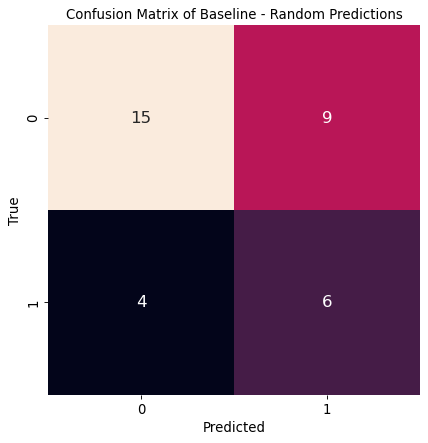

In [19]:
# Random guess
np.random.seed(8)
y_val_pred_random = np.random.choice([0, 1], size=len(y_val), p=[0.5, 0.5])

output_display(y_val, y_val_pred_random, model_name = "Baseline - Random Predictions")

The baseline of random predictions performed poorly with accuracy of 61.76%. AUC is only 61.25%, which indicates that the model has limited classification ability. Recall, precision and F1 score are all low.

### 2.3 Baseline - SGD classifier

In [20]:
# Avoid data leakage by using a pipleine.
preproc_pl = Pipeline([ ('imputer', SimpleImputer(strategy="median")),
                        ('std_scaler', StandardScaler())])

[Baseline - SGD Classifier]
 Accuracy: 0.9118
 Balanced Accuracy: 0.9375
 Recall: 1.0000
 Precision: 0.7692
 AUC: 0.9375
 F1 Score: 0.8696
 F-beta Score (beta=0.1): 0.7710
 F-beta Score (beta=10): 0.9970


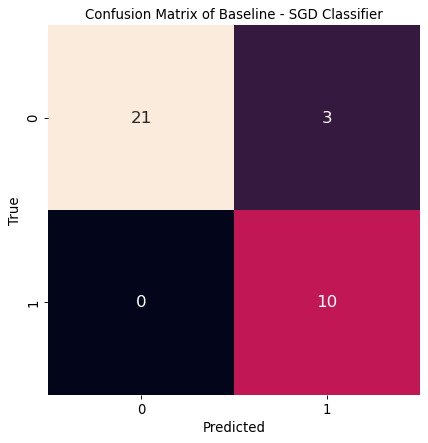

In [21]:
sgd_clf = Pipeline([('preproc',preproc_pl), ('sgd',SGDClassifier(random_state=8))])

sgd_clf.fit(X_train, y_train)
y_val_pred_sgd_baseline = sgd_clf.predict(X_val)

output_display(y_val, y_val_pred_sgd_baseline, model_name = "Baseline - SGD Classifier")

The baseline of SGD classifier performed well with accuracy of 0.9118 and AUC of 0.9375, which indicates the model has strong classification ability. Recall of 1.000 represents there is no false negative that no malignant case is classified to benign.

## 3. Model Optimisation [40%]

### 3.1 Performance metric



The baseline SGD classification meets the client's second requirement (FP/TN = 3/24 < 1/5) easily. However, satisfying the first requirement with a recall of 90% is challenging. Therefore, 'recall' is used as the metric for hyperparameter optimization to prioritize client needs.

### 3.2 Hyper-parameter optimisation
 - Perform a hyper-parameter optimisation (using appropriate methods) on three models:
   - SGD Classifer
   - SVM
   - One other model of your choice
 - Display the results of each model (including confusion matrices) and choose the best model.
 - Choose the best model and display the final results of this model.

#### 3.2.1 SGD Classifier

In [22]:
# SGD Classifier
sgd_pipeline = Pipeline([('preproc', preproc_pl), ('sgd', SGDClassifier(random_state=8))])

# Use ChatGPT to generate hyper-parameters
param_grid_sgd = {
    'sgd__loss': ['hinge', 'log_loss', 'modified_huber'],
    'sgd__penalty': ['l2', 'l1', 'elasticnet'],
    'sgd__eta0': [0.001, 0.01, 0.1],
    'sgd__power_t': [0.25, 0.5, 0.75]
}

best_params_sgd = None
best_score_sgd = 0

# Hyper-parameter optimisation on validation set
for loss in param_grid_sgd['sgd__loss']:
    for penalty in param_grid_sgd['sgd__penalty']:
        for eta0 in param_grid_sgd['sgd__eta0']:
            for power_t in param_grid_sgd['sgd__power_t']:
                
                sgd_pipeline.set_params(sgd__loss=loss, sgd__penalty=penalty, sgd__eta0=eta0, sgd__power_t=power_t)
                
                # Train the model and predict on validation set
                sgd_pipeline.fit(X_train, y_train)
                y_val_pred_sgd = sgd_pipeline.predict(X_val)
                
                # Calculate the recall
                score_sgd = recall_score(y_val, y_val_pred_sgd)
                
                # find the best paramaters with highest score(recall)
                if score_sgd > best_score_sgd:
                    best_score_sgd = score_sgd
                    best_params_sgd = {
                        'sgd__loss': loss,
                        'sgd__penalty': penalty,
                        'sgd__eta0': eta0,
                        'sgd__power_t': power_t
                    }


Best Parameters for SGD classifier: {'sgd__loss': 'hinge', 'sgd__penalty': 'l2', 'sgd__eta0': 0.001, 'sgd__power_t': 0.25}
Best Validation Score: 1.0
Test Score: 0.9

[SGD Classifier with Best Recall]
 Accuracy: 0.9394
 Balanced Accuracy: 0.9283
 Recall: 0.9000
 Precision: 0.9000
 AUC: 0.9283
 F1 Score: 0.9000
 F-beta Score (beta=0.1): 0.9000
 F-beta Score (beta=10): 0.9000


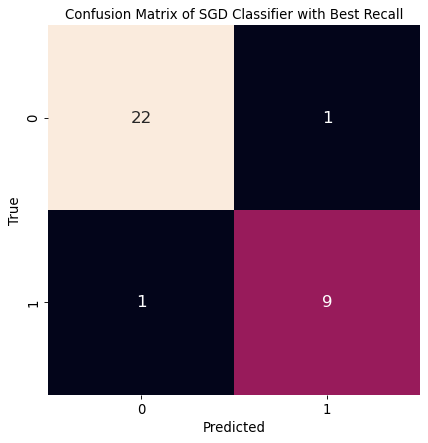

In [23]:
print(f"Best Parameters for SGD classifier: {best_params_sgd}")
print(f"Best Validation Score: {best_score_sgd}")

# Retrain the model with bigtrain dataset(contains train and validation set)
sgd_pipeline.set_params(**best_params_sgd)
sgd_pipeline.fit(X_bigtrain, y_bigtrain)

# Evaluate on test set
y_test_pred_sgd = sgd_pipeline.predict(X_test)
test_score_sgd = recall_score(y_test, y_test_pred_sgd)

print(f"Test Score: {test_score_sgd}\n")
output_display(y_test, y_test_pred_sgd, model_name="SGD Classifier with Best Recall")

#### 3.2.2 SVM

In [24]:
# SVM
svm_pipeline = Pipeline([('preproc', preproc_pl), ('svm', SVC(probability=True, random_state=8))])

# Use ChatGPT to generate hyper-parameters
svm_params = {
    'svm__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto']
}

best_params_svm = None
best_score_svm = 0

for kernel in svm_params['svm__kernel']:
    for C in svm_params['svm__C']:
        for gamma in svm_params['svm__gamma']:
            
            svm_pipeline.set_params(svm__kernel=kernel, svm__C=C, svm__gamma=gamma)            
            svm_pipeline.fit(X_train, y_train)
            y_val_pred_svm = svm_pipeline.predict(X_val)
            score_svm = recall_score(y_val, y_val_pred_svm)
            
            if score_svm > best_score_svm:
                best_score_svm = score_svm
                best_params_svm = {
                    'svm__kernel': kernel,
                    'svm__C': C,
                    'svm__gamma': gamma
                }


Best Parameters: {'svm__kernel': 'sigmoid', 'svm__C': 1, 'svm__gamma': 'scale'}
Best Validation Recall: 1.0
Test Recall: 0.8

[SVM with Best Recall]
 Accuracy: 0.9394
 Balanced Accuracy: 0.9000
 Recall: 0.8000
 Precision: 1.0000
 AUC: 0.9000
 F1 Score: 0.8889
 F-beta Score (beta=0.1): 0.9975
 F-beta Score (beta=10): 0.8016


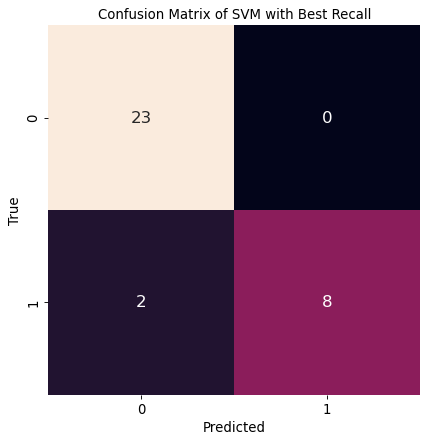

In [25]:
print(f"Best Parameters: {best_params_svm}")
print(f"Best Validation Recall: {best_score_svm}")

svm_pipeline.set_params(**best_params_svm)
svm_pipeline.fit(X_bigtrain, y_bigtrain)

y_test_pred_svm = svm_pipeline.predict(X_test)
test_score_svm = recall_score(y_test, y_test_pred_svm)
print(f"Test Recall: {test_score_svm}\n")

output_display(y_test, y_test_pred_svm, model_name="SVM with Best Recall")

#### 3.2.3 Random Forest

In [26]:
# Random Forest
rf_pipeline = Pipeline([('preproc', preproc_pl), ('rf', RandomForestClassifier(random_state=8))])

# Use ChatGPT to generate hyper-parameters
rf_params = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_leaf': [1, 2, 4]
}

best_params_rf = None
best_score_rf = 0

for n_estimators in rf_params['rf__n_estimators']:
    for max_depth in rf_params['rf__max_depth']:
        for min_samples_leaf in rf_params['rf__min_samples_leaf']:
            
            rf_pipeline.set_params(rf__n_estimators=n_estimators, rf__max_depth=max_depth, rf__min_samples_leaf=min_samples_leaf)            
            rf_pipeline.fit(X_train, y_train)            
            y_val_pred_rf = rf_pipeline.predict(X_val)
            score_rf = recall_score(y_val, y_val_pred_rf, average='macro')
            
            if score_rf > best_score_rf:
                best_score_rf = score_rf
                best_params_rf = {
                    'rf__n_estimators': n_estimators,
                    'rf__max_depth': max_depth,
                    'rf__min_samples_leaf': min_samples_leaf
                }


Best Parameters: {'rf__n_estimators': 50, 'rf__max_depth': None, 'rf__min_samples_leaf': 1}
Best Validation Recall: 0.9083333333333333
Test Recall: 0.7

[Random Forest with Best Recall]
 Accuracy: 0.9091
 Balanced Accuracy: 0.8500
 Recall: 0.7000
 Precision: 1.0000
 AUC: 0.8500
 F1 Score: 0.8235
 F-beta Score (beta=0.1): 0.9958
 F-beta Score (beta=10): 0.7021


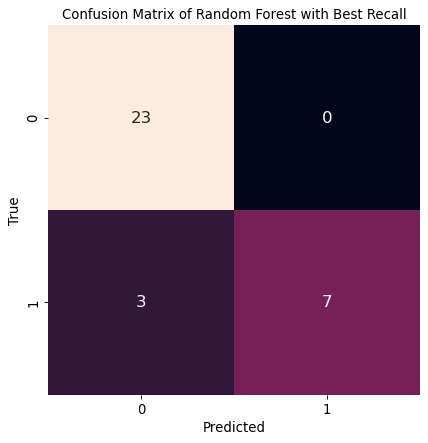

In [27]:
print(f"Best Parameters: {best_params_rf}")
print(f"Best Validation Recall: {best_score_rf}")

rf_pipeline.set_params(**best_params_rf)
rf_pipeline.fit(X_bigtrain, y_bigtrain)

y_test_pred_rf = rf_pipeline.predict(X_test)
test_score_rf = recall_score(y_test, y_test_pred_rf)
print(f"Test Recall: {test_score_rf}\n")

output_display(y_test, y_test_pred_rf, model_name="Random Forest with Best Recall")

#### 3.2.4 Find the best model

All the three optimized models performan well with a recall over 0.9 on the validation set. However, only when using SGD classifier meets the client's requirements with a recall of 0.9 on test set. Besides, SGD classifier results in highest AUC, which indicates the model has the best ability to deal with imbalance data and captures the trade-off between sensitivity and specificity.

[Best Model - SGD Classifier]
 Accuracy: 0.9394
 Balanced Accuracy: 0.9000
 Recall: 0.8000
 Precision: 1.0000
 AUC: 0.9000
 F1 Score: 0.8889
 F-beta Score (beta=0.1): 0.9975
 F-beta Score (beta=10): 0.8016


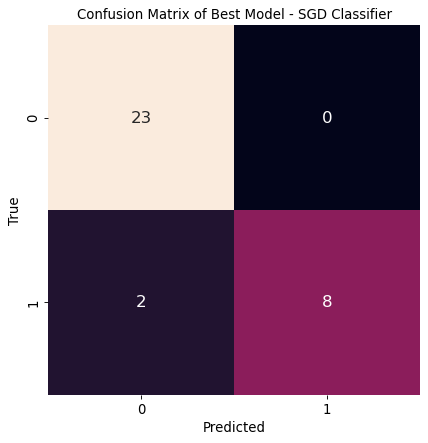

In [28]:
best_model = sgd_pipeline
y_test_pred_best = y_test_pred_svm

# Display final results for the best model
output_display(y_test, y_test_pred_best, model_name="Best Model - SGD Classifier")

### 3.3 Final results

From the final results calculate the _probability_ that a sample from a person with a malignant tumour is given a result that they do not have cancer.

In the final results of best model:  
- True positives(TP): 9 malignant case classified as malignant.  
- False positive(FP): 1 benign case classfied as malignant.  
- False negative(FN): 1 malignant data are classified to benign.  
- True negative(TN): 22 benign cases are correctly classified to benign.  
  
To calculate the *probability* is to calculate the proportion of misclassifications that treat 1 as 0(false negatives) in the overall malignant cases (TP+FN).  
  
  $$
\text{Probability} = \frac{FN}{TP + FN} = \frac{1}{9 + 1} = \frac{1}{10} = 0.10
$$


## 4. Decision Boundaries 

### 4.1 Discriminative features

Although it is only possible to know the true usefulness of a feature when you've combined it with others in a machine learning method, it is still helpful to have some measure for how discriminative each feature is on its own.  One common method for doing this is to calculate a T-score (often used in statistics, and in the LDA machine learning method) for each feature.  

The formula for the T-score is:

_(mean(x2) - mean(x1))/(0.5*(stddev(x2) + stddev(x1)))_

where x1 and x2 are the feature values corresponding to the two classes. Large values for the T-score (either positive or negative) indicate discriminative ability.

**Calculate the T-score for each feature and print out the best 4 features according to this score.**

In [29]:
t_score_list = []
for feature in features:
    x1 = data[data['new_label'] == 0][feature]
    x2 = data[data['new_label'] == 1][feature]
    mean_x1 = np.mean(x1)
    mean_x2 = np.mean(x2)
    std_x1 = np.std(x1)
    std_x2 = np.std(x2)
    t_score = (mean_x2 - mean_x1) / (0.5 * (std_x2 + std_x1))
    t_score_list.append((abs(t_score), feature))
    
t_score_list.sort(reverse=True)

print('The best 4 features with highest T-scores:')

for score, feature in t_score_list[:4]:
    print(f"{feature} : {score:.4f}")

The best 4 features with highest T-scores:
mean concave points : 2.3525
mean perimeter : 1.9398
mean radius : 1.8405
mean area : 1.8174


### 4.2 Visualise decision boundaries

**Display the decision boundaries** for each pair of features from the best 4 chosen above.  You can use the functions below to help if you like.

Instead of using the simple mean as the input for `xmean` in `plot_contours`, use the following:

_0.5*(mean(x1) + mean(x2))_

where x1 and x2 are the data associated with the two classes.  This way of calculating a "mean" point takes into account any imbalance between the classes.

In [30]:
def make_meshgrid(x, y, ns=100):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on (only min and max used)
    y: data to base y-axis meshgrid on (only min and max used)
    ns: number of steps in grid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    hx = (x_max - x_min)/ns
    hy = (y_max - y_min)/ns
    xx, yy = np.meshgrid(np.arange(x_min, x_max + hx, hx), np.arange(y_min, y_max + hy, hy))
    return xx, yy

In [31]:
def plot_contours(clf, xx, yy, xmean, n1, n2, feature_names, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    xmean : 1d array of N mean values (used to populate constant features with)
    n1, n2: index numbers of features that change
              that is, which features xx and yy represent, from the set of N features
    params: dictionary of params to pass to contourf, optional
    """
    # The following lines makes an MxN matrix to pass to the classifier (# samples x # features)
    # It does this by multiplying Mx1 and 1xN matrices, where the former is filled with 1's
    #  where M is the number of grid points in xx and N is the number of features in xmean
    #  It is done in such a way that the xmean vector is replaced in each row
    fullx = np.ones((xx.ravel().shape[0], len(xmean))) * xmean.values
    fullx[:,n1] = xx.ravel()
    fullx[:,n2] = yy.ravel()
    
    fullx_df = pd.DataFrame(fullx, columns=feature_names)# Create a dataframe with feature names
    
    Z = clf.predict(fullx_df)
    Z = Z.reshape(xx.shape)
    out = plt.contourf(xx, yy, Z, **params)
    return out

In [32]:
# Find the feature names of top 4 features
top_4_features = [i[1] for i in t_score_list[:4]]

# Mean Point
xmean = 0.5 * (X_test[y_test == 0].mean(axis=0) + X_test[y_test == 1].mean(axis=0))

# Feature Pairs
feature_pairs = [(i, j) for i in range(len(top_4_features)) for j in range(i + 1, len(top_4_features))]


In [33]:
import warnings
warnings.filterwarnings('ignore')

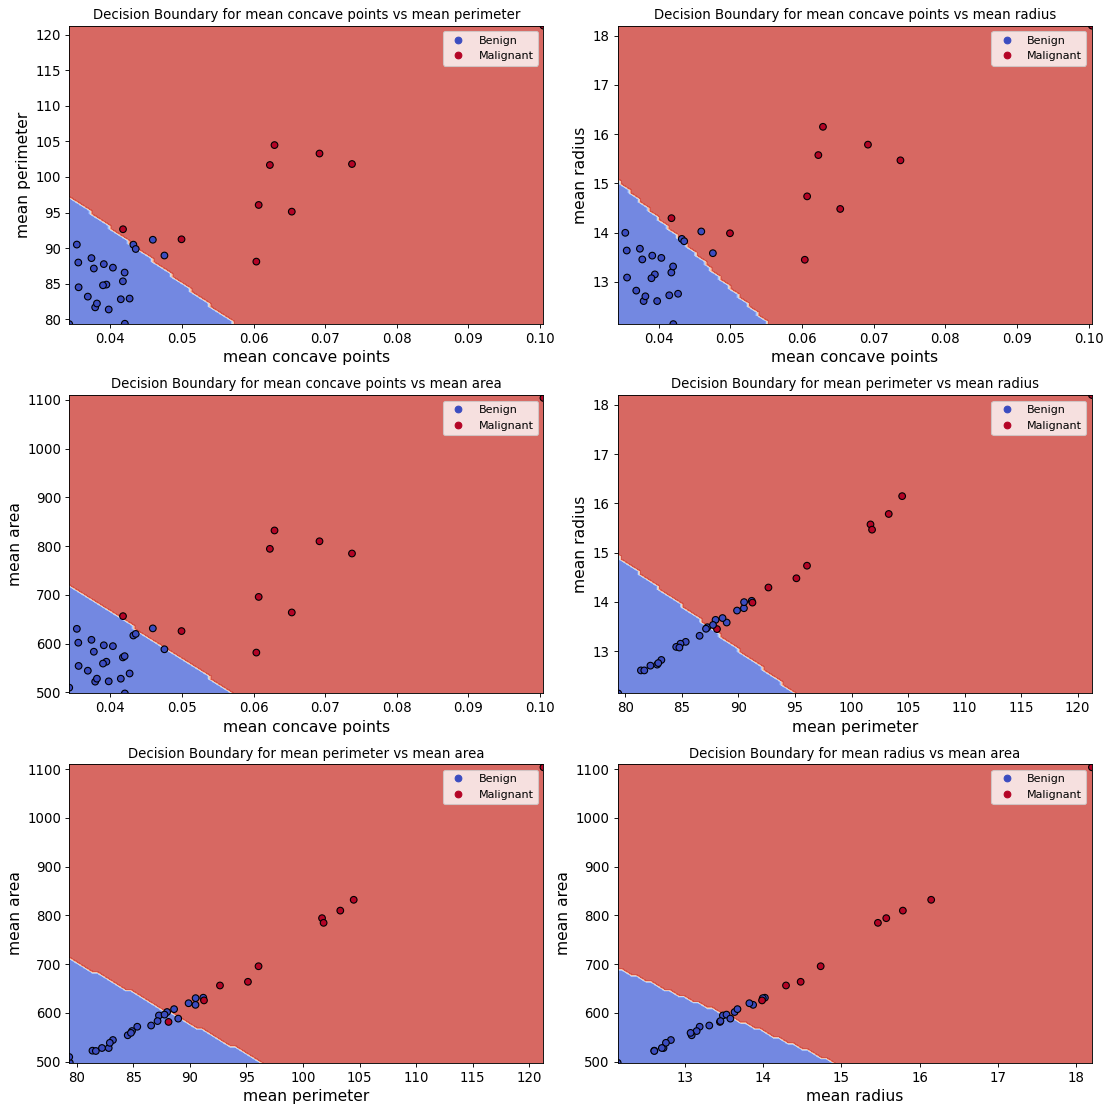

In [34]:
# Plot 6 six decision boundaries 
plt.figure(figsize=(14, 14))
for idx, (i, j) in enumerate(feature_pairs, 1):
    xx, yy = make_meshgrid(X_test[top_4_features[i]], X_test[top_4_features[j]])
    plt.subplot(3,2, idx)
    plot_contours(best_model, xx, yy, xmean, X_test.columns.get_loc(top_4_features[i]), X_test.columns.get_loc(top_4_features[j]), X_test.columns, cmap=plt.cm.coolwarm, alpha=0.8)
    scatter = plt.scatter(X_test[top_4_features[i]], X_test[top_4_features[j]], c=y_test, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.xlabel(top_4_features[i])
    plt.ylabel(top_4_features[j])
    plt.title(f"Decision Boundary for {top_4_features[i]} vs {top_4_features[j]}")
    plt.legend(handles=scatter.legend_elements()[0], labels=['Benign', 'Malignant'])


plt.tight_layout()
plt.show()


### 4.3 Performance specification

 It meets the client's requirements:  
- Recall = 0.9 = 90%.  
- Just 1 benign cases regarded as malignant so that (FP/(TN+FP) = 1/23 < 1/5).   
  
Aditionally, AUC (0.9283) of the best model highlights excellent discrimination ability and the consistent F1 and F-beta scores (0.9) represents the model's robust performance across different evaluation metrics, meeting the client's requirements effectively.